## Reinforcement Learning Strategy for Algorithmic Trading

In [ ]:
# Importing the libraries
from sentiment_lib import *

# Parameters
time_window = 60
ticker = "AAPL"
model = 'rppo'

In [9]:
# Importing the datasets
train_df = pd.read_csv(f"rl_dfs/train/{ticker}.csv", index_col=0)
train_df.index = pd.to_datetime(train_df.index)

test_df = pd.read_csv(f"rl_dfs/test/{ticker}.csv", index_col=0)
test_df.index = pd.to_datetime(test_df.index)

# Number of steps for each iteration
num_of_steps = train_df.shape[0] - time_window

In [10]:
# Parameters for training environment
train_kwargs = {
    "data": train_df,
    "ticker":ticker, 
    "time_window":time_window,
    "trade_cost":0.0004,
    "reward_logic":"log_position",
    "reward_scale":1E4,
    "only_long":False,
    "verbose":False
}

# Parameters for testing environment
test_kwargs = {
    "data": test_df,
    "ticker":ticker, 
    "time_window":time_window,
    "trade_cost":0.0004,
    "reward_logic":"log_position",
    "reward_scale":1E4,
    "only_long":False,
    "verbose":False
}

# Model parameters
model_parameters = {
    'n_steps': 80,
    'gamma': 0.995,
    'ent_coef': 0.005,
    'learning_rate': 0.0003
}

# Policy parameters
policy_kwargs = dict(
    net_arch=[dict(vf=[128, 128, 128], pi=[128, 128])],
    lstm_hidden_size=256,
    n_lstm_layers=2
)



In [ ]:
# Creating the pipeline and its processes
mt = MultiProcessingPipeline(ticker=ticker,
                             train_kwargs=train_kwargs, 
                             test_kwargs=test_kwargs,
                             n_process=3,
                             model=model)

mt.create_process_conditions(model_parameters, 
                             policy_parameters=policy_kwargs,
                             policy="MlpLstmPolicy", 
                             total_timesteps=num_of_steps*4)

In [5]:
#%tensorboard --logdir tensorboard_logs

In [7]:
# Training and testing the model
start = datetime.now()
mt.multi_tasking()

print(f"Training and testing time: {datetime.now() - start}")

Successfully load model results/20241228/AAPL/19h23/rppo_0/agent_rppo.zip
Successfully load model results/20241228/AAPL/19h23/rppo_2/agent_rppo.zip
Successfully load model results/20241228/AAPL/19h23/rppo_1/agent_rppo.zip
Training time: 0:06:40.222681



Results of process 0

==== Final Metrics ====
Total Return : 1.00
Sharpe Ratio : 0.01
Max Drawdown : 0.15
Hit Ratio : 0.28
Number of operations:  159


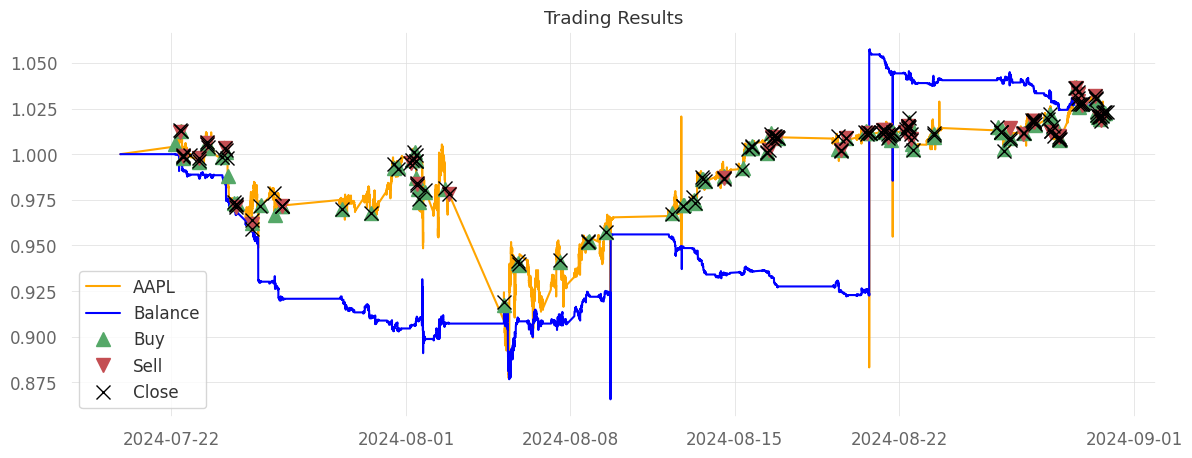


Results of process 2

==== Final Metrics ====
Total Return : 0.26
Sharpe Ratio : -0.09
Max Drawdown : 0.18
Hit Ratio : 0.29
Number of operations:  3638


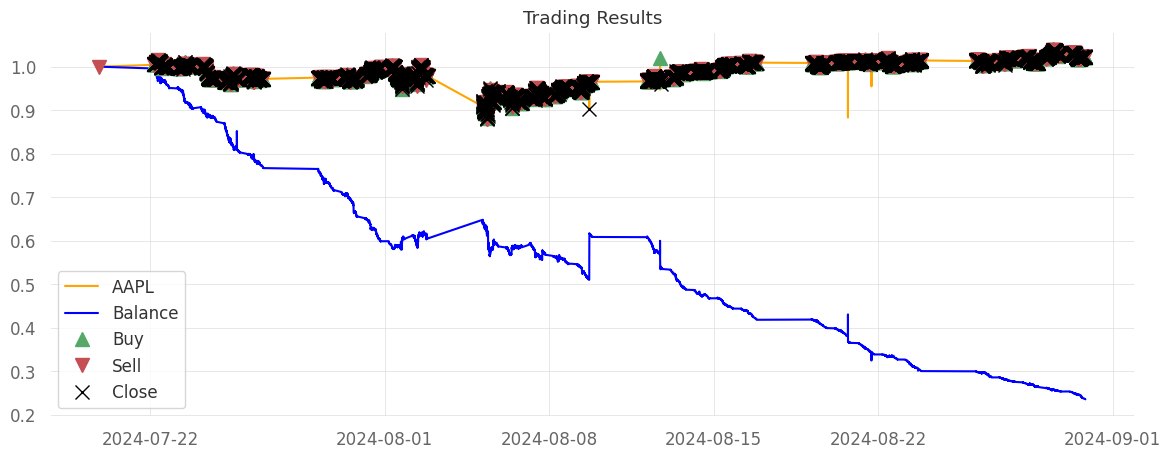


Results of process 1

==== Final Metrics ====
Total Return : 0.87
Sharpe Ratio : -0.05
Max Drawdown : 0.11
Hit Ratio : 0.31
Number of operations:  249


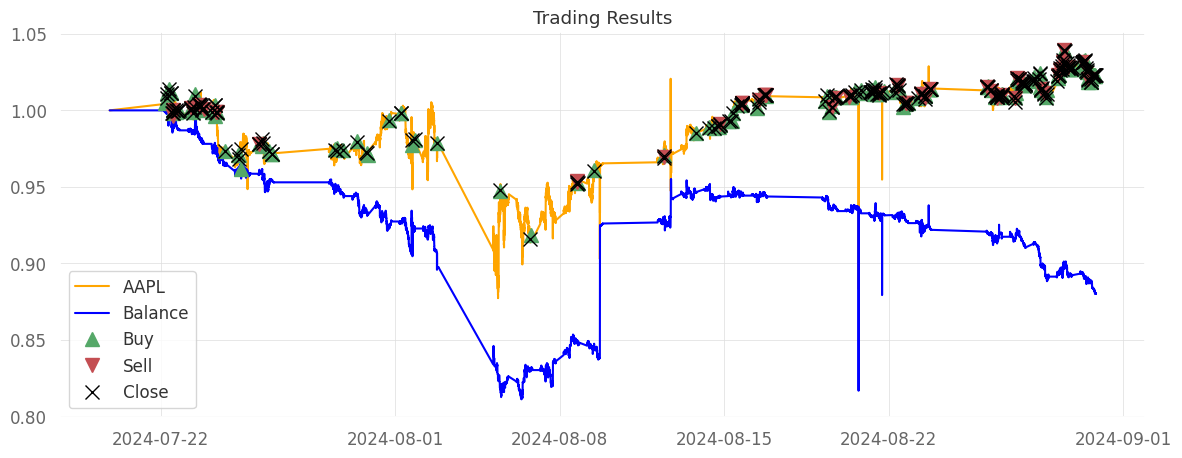

In [8]:
# Getting the results
mt.get_results()